In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler

In [12]:
import pandas as pd
import glob
import os

# =========================
# STEP 1: LOAD ALL CSV FILES
# =========================
folder_path = "Data"   # your folder name
files = glob.glob(os.path.join(folder_path, "*.csv"))

all_data = []

for file in files:
    try:
        df = pd.read_csv(file)

        # Standardize column names
        df.columns = df.columns.str.lower().str.strip()

        # Rename date column
        if 'date' in df.columns:
            df.rename(columns={'date': 'datetime'}, inplace=True)

        # Convert datetime
        df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

        # Extract ticker name from file
        ticker = os.path.basename(file).replace(".csv", "")
        df['ticker'] = ticker

        # Sort
        df = df.sort_values('datetime')

        # Keep required columns
        df = df[['datetime', 'open', 'high', 'low', 'close', 'volume', 'ticker']]

        all_data.append(df)

    except Exception as e:
        print(f"Error in file {file}: {e}")

# =========================
# STEP 2: MERGE ALL DATA
# =========================
df = pd.concat(all_data, ignore_index=True)

# =========================
# STEP 3: CLEAN DATA
# =========================
df = df.dropna()
df = df[df['volume'] > 0]

# Remove duplicates
df = df.drop_duplicates(subset=['datetime', 'ticker'])

# Sort properly
df = df.sort_values(['ticker', 'datetime']).reset_index(drop=True)

print("Total rows after merge:", len(df))

# =========================
# STEP 4: FEATURE ENGINEERING
# =========================

# Returns
df['returns'] = df.groupby('ticker')['close'].pct_change()

# Volatility
df['volatility'] = df.groupby('ticker')['returns'].rolling(10).std().reset_index(0, drop=True)

# Moving averages
df['ema_20'] = df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=20).mean())
df['ema_50'] = df.groupby('ticker')['close'].transform(lambda x: x.ewm(span=50).mean())

# RSI
def compute_rsi(series, window=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

df['rsi'] = df.groupby('ticker')['close'].transform(compute_rsi)

# Time features
df['hour'] = df['datetime'].dt.hour
df['minute'] = df['datetime'].dt.minute

# =========================
# STEP 5: TARGET CREATION (VERY IMPORTANT)
# =========================

# Future return
df['future_return'] = df.groupby('ticker')['close'].shift(-5) / df['close'] - 1

# Target
df['target'] = 0  # HOLD
df.loc[df['future_return'] > 0.002, 'target'] = 1  # BUY
df.loc[df['future_return'] < -0.002, 'target'] = 2  # SELL

# =========================
# STEP 6: FINAL CLEAN
# =========================
df = df.dropna().reset_index(drop=True)

print("Final dataset size:", len(df))
print(df['target'].value_counts())

# =========================
# SAVE FINAL DATASET
# =========================
df.to_csv("final_dataset.csv", index=False)

print("✅ Dataset ready for ML / LSTM")

Total rows after merge: 5949365
Final dataset size: 5941806
target
2    2094234
1    2036813
0    1810759
Name: count, dtype: int64
✅ Dataset ready for ML / LSTM


In [ ]:
# import yfinance as yf
# import pandas as pd
# from datetime import datetime, timedelta

# tickers = ["RELIANCE.NS", "TCS.NS", "INFY.NS"]

# def fetch_valid_intraday():
#     all_data = []

#     end_date = datetime.today()
#     start_date = end_date - timedelta(days=59)  # ONLY valid range

#     for ticker in tickers:
#         df = yf.download(
#             ticker,
#             start=start_date.strftime('%Y-%m-%d'),
#             end=end_date.strftime('%Y-%m-%d'),
#             interval="5m",
#             progress=False
#         )

#         if df.empty:
#             print(f"No data for {ticker}")
#             continue

#         df.columns = [col if isinstance(col, str) else col[0] for col in df.columns]
#         df = df[['Open','High','Low','Close','Volume']]

#         df['ticker'] = ticker
#         df.reset_index(inplace=True)

#         all_data.append(df)

#     df = pd.concat(all_data, ignore_index=True)

#     return df


# df = fetch_valid_intraday()
# print(len(df))

8148


In [15]:
import ta
import pandas as pd

def add_features(df):

    df = df.sort_values(['ticker', 'datetime']).reset_index(drop=True)

    feature_dfs = []

    for ticker, group in df.groupby('ticker'):

        group = group.copy()
        group = group.sort_values('datetime')

        if len(group) < 60:
            continue

        close = group['close'].astype(float)

        # Indicators
        group['rsi'] = ta.momentum.RSIIndicator(close, window=14).rsi()
        group['ema_20'] = ta.trend.EMAIndicator(close, window=20).ema_indicator()
        group['ema_50'] = ta.trend.EMAIndicator(close, window=50).ema_indicator()

        macd = ta.trend.MACD(close)
        group['macd'] = macd.macd()
        group['macd_signal'] = macd.macd_signal()

        bb = ta.volatility.BollingerBands(close, window=20)
        group['bb_upper'] = bb.bollinger_hband()
        group['bb_lower'] = bb.bollinger_lband()

        # Features
        group['returns'] = close.pct_change()
        group['volatility'] = group['returns'].rolling(10).std()

        # Time features
        group['hour'] = group['datetime'].dt.hour
        group['minute'] = group['datetime'].dt.minute

        group = group.dropna()

        feature_dfs.append(group)

    return pd.concat(feature_dfs, ignore_index=True)


# Apply
df = add_features(df)

print("After feature engineering:", df.shape)
df.head()

After feature engineering: (5936906, 20)


,datetime,open,high,low,close,volume,ticker,returns,volatility,ema_20,ema_50,rsi,hour,minute,future_return,target,macd,macd_signal,bb_upper,bb_lower
0,2015-02-04 12:15:00,996.90,996.90,993.8,995.95,1999,ABB_15minute,-0.000953,0.002034,995.083453,992.980038,52.755211,12,15,-0.002159,2,1.228207,1.275767,1001.652319,988.337681
1,2015-02-04 12:30:00,995.95,995.95,993.8,993.90,1119,ABB_15minute,-0.002058,0.001353,994.970743,993.016115,48.970262,12,30,0.002968,1,0.985815,1.217777,1001.655345,988.419655
2,2015-02-04 12:45:00,993.90,995.95,993.9,995.90,457,ABB_15minute,0.002012,0.001390,995.059244,993.129208,52.547245,12,45,0.001004,0,0.944216,1.163065,1001.743033,988.616967
3,2015-02-04 13:00:00,995.85,995.85,993.8,995.25,271,ABB_15minute,-0.000653,0.001410,995.077411,993.212377,51.288942,13,0,-0.000151,0,0.849013,1.100254,1001.778892,988.806108
4,2015-02-04 13:15:00,995.25,995.30,993.8,995.15,249,ABB_15minute,-0.000100,0.001401,995.084324,993.288362,51.086262,13,15,-0.000201,0,0.756771,1.031558,1001.805943,988.864057


In [16]:
def create_labels(df, horizon=8, sl=-0.01, tp=0.008):
    df = df.sort_values(['ticker', 'datetime'])
    final_df = []

    for ticker, group in df.groupby('ticker'):
        group = group.copy()
        close = group['close'].values

        labels = np.ones(len(group))

        for i in range(len(group) - horizon):
            entry = close[i]
            future = close[i+1:i+horizon]

            label = 1

            for price in future:
                change = (price - entry) / entry

                if change >= tp:
                    label = 2
                    break
                elif change <= sl:
                    label = 0
                    break

            labels[i] = label

        group['target'] = labels
        final_df.append(group)

    return pd.concat(final_df, ignore_index=True)

df = create_labels(df)

print(df['target'].value_counts())

target
1.0    3778723
2.0    1286479
0.0     871704
Name: count, dtype: int64


In [17]:
print(df['target'].value_counts())
# df.to_csv('h1.csv', index=False)

target
1.0    3778723
2.0    1286479
0.0     871704
Name: count, dtype: int64


In [19]:
print("\n🔵 BUY SAMPLES:")
print(df[df['target'] == 2][['datetime','ticker','close']].head(10))

print("\n🔴 SELL SAMPLES:")
print(df[df['target'] == 0][['datetime','ticker','close']].head(10))

print("\n⚪ HOLD SAMPLES:")
print(df[df['target'] == 1][['datetime','ticker','close']].head(10))


🔵 BUY SAMPLES:
              datetime        ticker   close
32 2015-02-05 14:00:00  ABB_15minute  991.20
33 2015-02-05 14:15:00  ABB_15minute  989.90
34 2015-02-05 14:30:00  ABB_15minute  989.30
35 2015-02-05 14:45:00  ABB_15minute  990.45
36 2015-02-05 15:00:00  ABB_15minute  989.30
37 2015-02-05 15:15:00  ABB_15minute  989.10
81 2015-02-09 13:45:00  ABB_15minute  990.65
82 2015-02-09 14:00:00  ABB_15minute  993.00
83 2015-02-09 14:15:00  ABB_15minute  984.35
84 2015-02-09 14:30:00  ABB_15minute  986.40

🔴 SELL SAMPLES:
               datetime        ticker    close
63  2015-02-09 09:15:00  ABB_15minute  1002.40
64  2015-02-09 09:30:00  ABB_15minute  1001.60
78  2015-02-09 13:00:00  ABB_15minute   994.60
80  2015-02-09 13:30:00  ABB_15minute   994.55
103 2015-02-10 13:00:00  ABB_15minute  1045.65
109 2015-02-10 14:30:00  ABB_15minute  1071.05
113 2015-02-11 09:15:00  ABB_15minute  1086.20
114 2015-02-11 09:30:00  ABB_15minute  1085.25
115 2015-02-11 09:45:00  ABB_15minute  1082.95
11

In [20]:
def apply_trading_logic(df):
    df = df.copy()
    
    position = 0
    final_signal = []

    for i in range(len(df)):
        signal = df.iloc[i]['target']
        trend_ok = df.iloc[i]['trend_ok']

        if position == 0:
            # 🔥 BUY only in uptrend
            if signal == 2 and trend_ok:
                final_signal.append(2)
                position = 1
            else:
                final_signal.append(1)

        elif position == 1:
            if signal == 0:
                final_signal.append(0)
                position = 0
            else:
                final_signal.append(1)

    df['final_signal'] = final_signal
    return df

In [21]:
df['trend_ok'] = df['ema_20'] > df['ema_50']
df = apply_trading_logic(df)

In [24]:
import matplotlib.pyplot as plt

def plot_signals(df, ticker_name):

    data = df[df['ticker'] == ticker_name].copy()

    if data.empty:
        print("No data found for ticker:", ticker_name)
        return

    # Sort properly
    data = data.sort_values('datetime')

    plt.figure(figsize=(15,6))

    # Price line
    plt.plot(data['datetime'], data['close'], label='Close Price')

    # Signals (correct mapping)
    buy = data[data['final_signal'] == 1]
    sell = data[data['final_signal'] == 2]

    plt.scatter(buy['datetime'], buy['close'], marker='^', label='BUY')
    plt.scatter(sell['datetime'], sell['close'], marker='v', label='SELL')

    plt.title(f"{ticker_name} Trading Signals")
    plt.xlabel("Time")
    plt.ylabel("Price")

    plt.legend()
    plt.grid()

    plt.show()



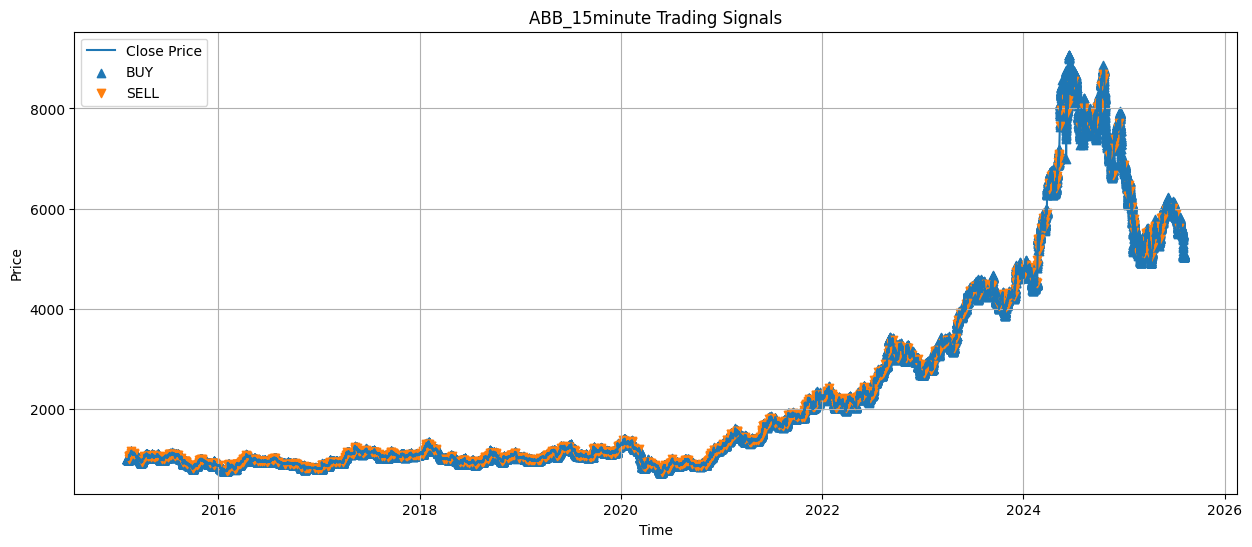

In [25]:
plot_signals(df, "ABB_15minute")

In [27]:
df['momentum_3'] = df['close'] / df['close'].shift(3) - 1
df['momentum_5'] = df['close'] / df['close'].shift(5) - 1

df['trend'] = df['ema_20'] - df['ema_50']
df['price_above_ema'] = df['close'] - df['ema_20']

df['volume_spike'] = df['volume'] / df['volume'].rolling(10).mean()

In [28]:
# Momentum
df['momentum_3'] = df.groupby('ticker')['close'].pct_change(3)
df['momentum_5'] = df.groupby('ticker')['close'].pct_change(5)

# Trend
df['trend'] = df['ema_20'] - df['ema_50']

# Price above EMA
df['price_above_ema'] = (df['close'] > df['ema_20']).astype(int)

# Volume spike
df['volume_spike'] = df['volume'] / df.groupby('ticker')['volume'].rolling(20).mean().reset_index(0, drop=True)

In [29]:
df['ticker_id'] = df['ticker'].astype('category').cat.codes

In [30]:
df = df.dropna().reset_index(drop=True)

In [31]:
features = [
    'rsi', 'ema_20', 'ema_50', 'macd',
    'bb_upper', 'bb_lower',
    'volatility',
    'momentum_3', 'momentum_5',
    'trend', 'price_above_ema',
    'volume_spike',
    'hour', 'minute',          # time features
    'ticker_id'                # VERY IMPORTANT
]

In [32]:
X = df[features]
y = df['target']

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("Before weighting:")
print(y_train.value_counts())

Before weighting:
target
1.0    3024356
2.0    1026623
0.0     697025
Name: count, dtype: int64


In [131]:
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, shuffle=False
# )

# print("Before SMOTE:")
# print(y_train.value_counts())

In [132]:
# smote = SMOTE(random_state=42)

# X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# print("\nAfter SMOTE:")
# print(pd.Series(y_train_sm).value_counts())

In [34]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))

print("Class weights:", class_weight_dict)

Class weights: {0.0: 2.2706043542197194, 1.0: 0.5233074413197388, 2.0: 1.5416253093881591}


In [35]:
weights = y_train.map(class_weight_dict)

In [36]:
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',   # faster training
    random_state=42
)

In [37]:
model.fit(
    X_train,
    y_train,
    sample_weight=weights,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=True
)

[0]	validation_0-mlogloss:1.10086	validation_1-mlogloss:1.10099
[1]	validation_0-mlogloss:1.09583	validation_1-mlogloss:1.09617
[2]	validation_0-mlogloss:1.09104	validation_1-mlogloss:1.09154
[3]	validation_0-mlogloss:1.08694	validation_1-mlogloss:1.08763
[4]	validation_0-mlogloss:1.08243	validation_1-mlogloss:1.08331
[5]	validation_0-mlogloss:1.08028	validation_1-mlogloss:1.08129
[6]	validation_0-mlogloss:1.07604	validation_1-mlogloss:1.07722
[7]	validation_0-mlogloss:1.07244	validation_1-mlogloss:1.07379
[8]	validation_0-mlogloss:1.06915	validation_1-mlogloss:1.07066
[9]	validation_0-mlogloss:1.06538	validation_1-mlogloss:1.06706
[10]	validation_0-mlogloss:1.06357	validation_1-mlogloss:1.06526
[11]	validation_0-mlogloss:1.05995	validation_1-mlogloss:1.06178
[12]	validation_0-mlogloss:1.05676	validation_1-mlogloss:1.05874
[13]	validation_0-mlogloss:1.05366	validation_1-mlogloss:1.05579
[14]	validation_0-mlogloss:1.05057	validation_1-mlogloss:1.05281
[15]	validation_0-mlogloss:1.04732	

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [38]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)

In [39]:
from sklearn.metrics import classification_report, confusion_matrix

print("CONFUSION MATRIX:")
print(confusion_matrix(y_test, y_pred))

print("\nCLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred))

CONFUSION MATRIX:
[[ 69068  43342  61772]
 [145228 459202 149000]
 [ 87248  67400 104742]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

         0.0       0.23      0.40      0.29    174182
         1.0       0.81      0.61      0.69    753430
         2.0       0.33      0.40      0.36    259390

    accuracy                           0.53   1187002
   macro avg       0.46      0.47      0.45   1187002
weighted avg       0.62      0.53      0.56   1187002



In [40]:
import pandas as pd

importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance.head(15))

            feature  importance
12             hour    0.385845
6        volatility    0.167410
13           minute    0.112841
5          bb_lower    0.056507
7        momentum_3    0.044242
8        momentum_5    0.038075
11     volume_spike    0.034563
10  price_above_ema    0.028510
14        ticker_id    0.026983
9             trend    0.023879
1            ema_20    0.023793
2            ema_50    0.017558
0               rsi    0.013573
4          bb_upper    0.013159
3              macd    0.013062


In [142]:
import numpy as np

probs = model.predict_proba(X_test)

buy_prob = probs[:, 2]
sell_prob = probs[:, 0]
hold_prob = probs[:, 1]

y_pred = np.ones(len(probs))  # HOLD default

for i in range(len(probs)):

    # 🔥 STRONG BUY
    if buy_prob[i] > sell_prob[i] and buy_prob[i] > hold_prob[i] * 0.6:
        y_pred[i] = 2

    # 🔥 STRONG SELL
    elif sell_prob[i] > buy_prob[i] and sell_prob[i] > hold_prob[i] * 0.6:
        y_pred[i] = 0

    else:
        y_pred[i] = 1

y_pred = y_pred.astype(int)

In [143]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[   3   57    0]
 [  10 2376    0]
 [   1  142    0]]


In [144]:
print(np.percentile(buy_prob, [50, 75, 90, 95, 99]))

[0.00197171 0.005631   0.0159654  0.0248588  0.05374063]


In [145]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

         0.0       0.21      0.05      0.08        60
         1.0       0.92      1.00      0.96      2386
         2.0       0.00      0.00      0.00       143

    accuracy                           0.92      2589
   macro avg       0.38      0.35      0.35      2589
weighted avg       0.86      0.92      0.88      2589


Confusion Matrix:

[[   3   57    0]
 [  10 2376    0]
 [   1  142    0]]


c:\Users\harsh\agentic-nifty50-signal-assistant\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\harsh\agentic-nifty50-signal-assistant\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\harsh\agentic-nifty50-signal-assistant\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [119]:
import numpy as np

buy_prob = probs[:, 2]

print("Max BUY prob:", np.max(buy_prob))
print("Mean BUY prob:", np.mean(buy_prob))

Max BUY prob: 0.2546899
Mean BUY prob: 0.0069665406


In [120]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

def create_sequences(X, y, seq_length=10):
    X_seq, y_seq = [], []

    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i+seq_length])
        y_seq.append(y.iloc[i+seq_length])

    return np.array(X_seq), np.array(y_seq)

X_seq, y_seq = create_sequences(X_scaled, y)

split = int(0.8 * len(X_seq))

X_train_lstm, X_test_lstm = X_seq[:split], X_seq[split:]
y_train_lstm, y_test_lstm = y_seq[:split], y_seq[split:]

In [121]:
model_lstm = Sequential()

model_lstm.add(LSTM(64, return_sequences=True, input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])))
model_lstm.add(Dropout(0.2))

model_lstm.add(LSTM(32))
model_lstm.add(Dropout(0.2))

model_lstm.add(Dense(3, activation='softmax'))

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.fit(
    X_train_lstm, y_train_lstm,
    epochs=5,
    batch_size=32,
    validation_data=(X_test_lstm, y_test_lstm)
)

c:\Users\harsh\agentic-nifty50-signal-assistant\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - accuracy: 0.9123 - loss: 0.3734 - val_accuracy: 0.9215 - val_loss: 0.3230
Epoch 2/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9164 - loss: 0.3479 - val_accuracy: 0.9215 - val_loss: 0.3270
Epoch 3/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9166 - loss: 0.3387 - val_accuracy: 0.9215 - val_loss: 0.3470
Epoch 4/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9167 - loss: 0.3282 - val_accuracy: 0.9215 - val_loss: 0.3134
Epoch 5/5
324/324 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9166 - loss: 0.3223 - val_accuracy: 0.9215 - val_loss: 0.3171


In [122]:
y_pred_lstm = np.argmax(model_lstm.predict(X_test_lstm), axis=1)

print("LSTM Confusion Matrix:\n")
print(confusion_matrix(y_test_lstm, y_pred_lstm))

81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM Confusion Matrix:

[[   0   60    0]
 [   0 2384    0]
 [   0  143    0]]
